# <span style="color:red"> **LSN - Esercitazione 11**
### <span style="color:green"> 29.05.2025
#### <span style="color:green"> Lucrezia Bioni (13655A)

### <span style="color:blue">**_Keras - Regressione lineare con Neural Network_**

Lo scopo di questa esercitazione è affrontare un problema di regressione su dati rumorosi usando una Rete Neurale (NN). In particolare, si vuole mostrare come la capacità di approssimazione dipenda dalla struttura della NN (numero di layer, neuroni, funzioni di attivazione), perché la predizione risulta complessa in presenza di rumore e quali sono le strategie per migliorare l'accuratezza del modello. L'obiettivo è sviluppare un'intuizione pratica sui compromessi tra sottodattamento (modello troppo semplice), sovradattamento (modello troppo complesso) e generalizzazione (prestazioni su dati mai visti).

**Il Problema della Predizione**
Si consideri un processo probabilistico che genera dati etichettati $(x,y)$. I dati sono prodotti estraendo campioni dall'equazione: $y_i = f(x_i) + \eta_i
$, dove $f(x_i)$ è una funzione fissa (potenzialmente sconosciuta), $\eta_i$ è un rumore gaussiano scorrelato con proprietà: $
  \langle \eta_i \rangle = 0 , \langle \eta_i \eta_j \rangle = \delta_{ij} \sigma
  $. Si chiamino $f(x_i)$ le caratteristiche vere del processo generatore. Per fare predizioni, si è utilizzata una NN con parametri (pesi e bias). Le funzioni che la NN può rappresentare costituiscono la classe di modelli disponibile per approssimare i dati. Per apprendere i parametri della rete, si sono allenati i modelli su un set di dati di training. Si è poi utilizzato un set di dati di validazione per testare le predizioni su dati mai visti, al fine di valutare la capacità di generalizzazione della rete. Si è misurata la performance della rete calcolando l'errore quadratico medio (MSE) tra i valori predetti dalla rete $\{y_j^\mathrm{pred}\}$  e i valori veri $\{y_j\}$:
     $$ MSE = \frac{1}{N_\mathrm{test}}\sum_{j=1}^{N_\mathrm{test}} (y_j^\mathrm{pred}-y_j)^2 $$

## <span style="color:blue">**Esercizio 11.1**

Lo scopo dell'esercizio è effettuare il fit lineare della funzione $f(x)=2x+1$ tramite una rete neurale, e individuare i parametri che consentano di ottenere i migliori risultati.

Innanzitutto, si sono definiti i parametri della funzione lineare ideale di cui si vuole effettuare il fit.

In [22]:
# target parameters of f(x) = m*x + b
m = 2 # slope
b = 1 # intersect

Si è poi generato un set di dati di input che deviano dal comportamento ideale, tramite l'introduzione di rumore:

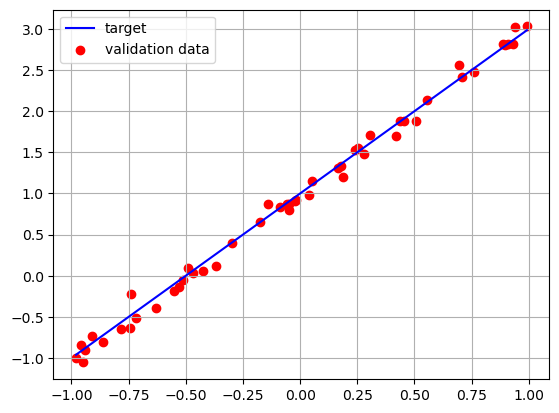

In [23]:
import numpy as np

# generate training inputs
np.random.seed(0)
x_train = np.random.uniform(-1, 1, 1000)
x_valid = np.random.uniform(-1, 1, 50)
x_valid.sort()
y_target = m * x_valid + b # ideal (target) linear function

sigma = 0.1 # noise standard deviation
y_train = np.random.normal(m * x_train + b, sigma) # actual measures from which we want to guess regression parameters
y_valid = np.random.normal(m * x_valid + b, sigma)

# plot validation and target dataset
import matplotlib.pyplot as plt
plt.plot(x_valid, y_target, label='target', color='b')
plt.scatter(x_valid, y_valid, color='r', label='validation data')
plt.legend()
plt.grid(True)
plt.show()

Si è realizzato un modello sequenziale costituito da un singolo neurone:

In [24]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# compose the NN model
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects

model = tf.keras.Sequential()
model.add(Dense(1, input_shape=(1,)))

# compile the model choosing optimizer, loss and metrics objects
model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

# get a summary of our composed model
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

Dopo aver realizzato il modello, lo si è allenato con un set di coppie di dati (`x_train`, `y_train`), tramite il quale l'ottimizzatore (`stochastic gradient descent`) trova i migliori pesi per minimizzare la funzione di loss costituita dall'errore quadratico medio. 

In [25]:
# fit the model using training dataset
# over 10 epochs of 32 batch size each
# report training progress against validation data
history = model.fit(x=x_train, y=y_train, 
          batch_size=32, epochs=30,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          validation_data=(x_valid, y_valid))

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8004 - mse: 0.8004 - val_loss: 0.2933 - val_mse: 0.2933
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2533 - mse: 0.2533 - val_loss: 0.0961 - val_mse: 0.0961
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0877 - mse: 0.0877 - val_loss: 0.0402 - val_mse: 0.0402
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0344 - mse: 0.0344 - val_loss: 0.0227 - val_mse: 0.0227
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0206 - mse: 0.0206 - val_loss: 0.0166 - val_mse: 0.0166
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0154 - mse: 0.0154 - val_loss: 0.0139 - val_mse: 0.0139
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0135 - mse: 0.0135 - val_loss: 0.0123 - val_mse: 0.0123
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0106 - mse: 0.0106 - val_loss: 0.0112 - val_mse: 0.0112
Epoch 9/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0106 - mse: 

By looking at weights and biases we can see if the linear fit was successfull: $w_1$ represents the angular coefficient, $b$ the intercept.

In [26]:
# return weights and biases
model.get_weights()

[array([[1.9963963]], dtype=float32), array([1.0026507], dtype=float32)]

In [27]:
# evaluate model
score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0088 - mse: 0.0088

Test loss: 0.008392440155148506
Test accuracy: 0.008392440155148506


In [28]:
# evaluate model with the exact curve
score = model.evaluate(x_valid, y_target, batch_size=32, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.4426e-05 - mse: 1.4426e-05

Test loss: 1.2313623301452026e-05
Test accuracy: 1.2313623301452026e-05


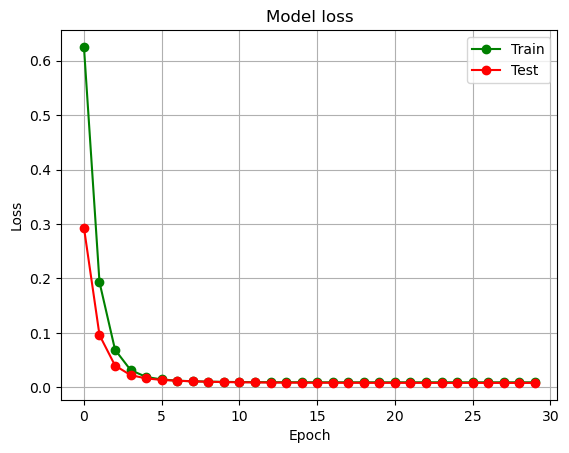

In [34]:
# look into training history
# Plot training & validation loss values
plt.plot(history.history['loss'], 'go-')
plt.plot(history.history['val_loss'], 'ro-')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.grid('true')
plt.show()

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7d647461b880> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


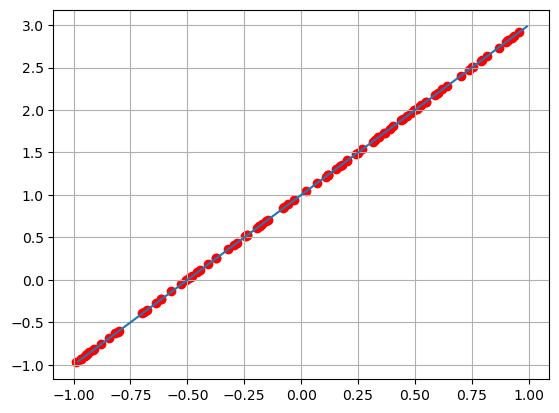

In [30]:
x_predicted = np.random.uniform(-1, 1, 100)
y_predicted = model.predict(x_predicted)
plt.scatter(x_predicted, y_predicted,color='r')
plt.plot(x_valid, y_target)
plt.grid(True)
plt.show()